## 1) Setup & Imports

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

ROOT_DIR = Path('.')          # notebook lives in decision-intelligence-assistant/
DATA_DIR = ROOT_DIR / 'data'
DATA_DIR.mkdir(exist_ok=True)

# Primary: local copy already in this project
RAW_CSV = DATA_DIR / 'raw-data' / 'twcs.csv'

CLEAN_CSV = DATA_DIR / 'clean_tickets.csv'
RANDOM_STATE = 42
SAMPLE_SIZE = 50_000

print(f'RAW_CSV resolved to: {RAW_CSV}')
print(f'Exists: {RAW_CSV.exists()}')

RAW_CSV resolved to: data\raw-data\twcs.csv
Exists: True


### Notes

Standard data science imports. TextBlob is used only in Section 12 for offline sentiment scoring.

SAMPLE_SIZE = 50,000: the full dataset is 3M tweets. 50K gives enough signal while keeping TextBlob under a few minutes.

## 2) Load Raw Data

In [185]:
df_raw = pd.read_csv(
    RAW_CSV,
    dtype={'tweet_id': str, 'in_response_to_tweet_id': str, 'response_tweet_id': str}
)
print(f'Raw shape: {df_raw.shape}')
print(f'\nDtype overview:\n{df_raw.dtypes}')
df_raw.head(3)

Raw shape: (2811774, 7)

Dtype overview:
tweet_id                    str
author_id                   str
inbound                    bool
created_at                  str
text                        str
response_tweet_id           str
in_response_to_tweet_id     str
dtype: object


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4


### Notes

Tweet IDs are forced to `str` at read time. Pandas would silently cast them to int64, causing join mismatches on numeric-looking IDs.

`inbound=True` is the customer side. `inbound=False` is the company reply.

## 3) Join & Sample

In [186]:
# Separate inbound (customer) and outbound (company reply) tweets
inbound = df_raw[df_raw['inbound'] == True].copy()
outbound = df_raw[df_raw['inbound'] == False].copy()

print(f'Inbound (customer) tweets:  {len(inbound):,}')
print(f'Outbound (company) replies: {len(outbound):,}')

# Slim outbound to only what we need for the join
outbound_slim = outbound[['tweet_id', 'text', 'created_at']].rename(columns={
    'tweet_id': 'reply_tweet_id',
    'text': 'reply_text',
    'created_at': 'reply_created_at'
})

# Join: inbound.response_tweet_id == outbound.reply_tweet_id
# response_tweet_id on the inbound row is the tweet_id of the company's reply
pairs = inbound.merge(
    outbound_slim,
    left_on='response_tweet_id',
    right_on='reply_tweet_id',
    how='inner'
)

print(f'\nPairs after join: {pairs.shape}')
pairs.head(2)

Inbound (customer) tweets:  1,537,843
Outbound (company) replies: 1,273,931

Pairs after join: (1016105, 10)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,reply_tweet_id,reply_text,reply_created_at
0,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4,1,@115712 I understand. I would like to assist y...,Tue Oct 31 22:10:47 +0000 2017
1,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6,4,@115712 Please send us a Private Message so th...,Tue Oct 31 21:54:49 +0000 2017


In [187]:
if len(pairs) > SAMPLE_SIZE:
    pairs = pairs.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
print(f'Sampled pairs: {pairs.shape}')

Sampled pairs: (50000, 10)


### Notes

We store tweet+reply pairs, not just customer tweets. Storing only complaints gives the LLM no resolution context, making RAG and non-RAG answers nearly identical.

Inner join excludes unanswered tweets intentionally: we need a reply timestamp for the labeling function.

50K sampled with random_state=42 for reproducibility.

## 4) General EDA

=== Dataset Overview ===
Total pairs: 50,000

Null counts:
text                0
reply_text          0
created_at          0
reply_created_at    0
dtype: int64


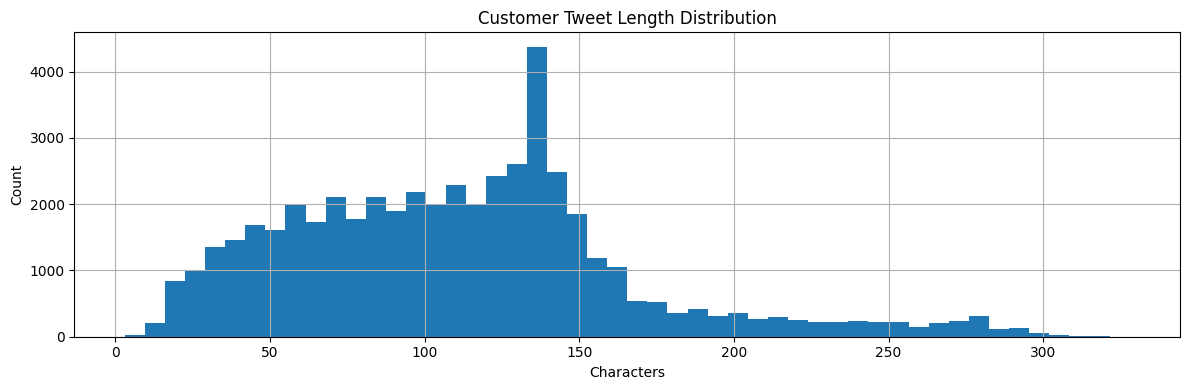


Tweet length stats:
count    50000.000000
mean       110.988740
std         55.523333
min          3.000000
25%         69.000000
50%        110.000000
75%        139.000000
max        328.000000
Name: tweet_length, dtype: float64


In [188]:
print('=== Dataset Overview ===')
print(f'Total pairs: {len(pairs):,}')
print(f'\nNull counts:')
print(pairs[['text', 'reply_text', 'created_at', 'reply_created_at']].isnull().sum())

pairs['tweet_length'] = pairs['text'].str.len()

fig, ax = plt.subplots(figsize=(12, 4))

pairs['tweet_length'].hist(bins=50, ax=ax)
ax.set_title('Customer Tweet Length Distribution')
ax.set_xlabel('Characters')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'\nTweet length stats:')
print(pairs['tweet_length'].describe())

### Notes

Most tweets are short given the 140-character limit. Tweets near 0 characters are likely bare @-mention messages with no real content.

## 5) Response Time EDA

Response time stats (minutes):
count    48259.000000
mean       101.225054
std        215.746765
min          0.016667
25%          5.416667
50%         17.250000
75%         75.950000
max       1440.000000
Name: response_time_min, dtype: float64

30th percentile: 6.9 min
Negative response times (data anomaly): 0
Response times > 24h (excluded): 1,741


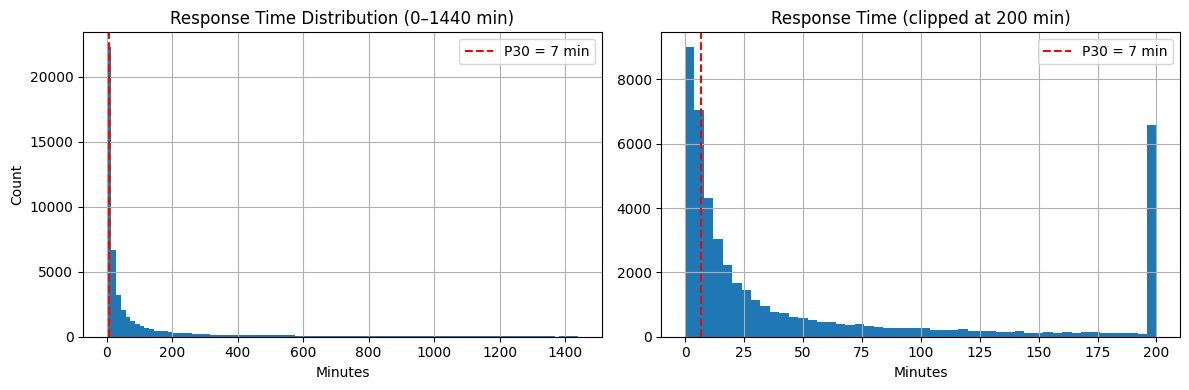


Using fast reply threshold: 6.9 min


In [189]:
pairs['created_at'] = pd.to_datetime(pairs['created_at'])
pairs['reply_created_at'] = pd.to_datetime(pairs['reply_created_at'])
pairs['response_time_min'] = (
    pairs['reply_created_at'] - pairs['created_at']
).dt.total_seconds() / 60

# Filter to plausible range (0 to 1440 min = 24 hours)
valid_rt = pairs[
    (pairs['response_time_min'] >= 0) &
    (pairs['response_time_min'] <= 1440)
]

p30 = valid_rt['response_time_min'].quantile(0.30)
print(f'Response time stats (minutes):\n{valid_rt["response_time_min"].describe()}')
print(f'\n30th percentile: {p30:.1f} min')
print(f'Negative response times (data anomaly): {(pairs["response_time_min"] < 0).sum():,}')
print(f'Response times > 24h (excluded): {(pairs["response_time_min"] > 1440).sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

valid_rt['response_time_min'].hist(bins=100, ax=axes[0])
axes[0].axvline(p30, color='red', linestyle='--', label=f'P30 = {p30:.0f} min')
axes[0].set_title('Response Time Distribution (0–1440 min)')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Count')
axes[0].legend()

valid_rt['response_time_min'].clip(upper=200).hist(bins=50, ax=axes[1])
axes[1].axvline(p30, color='red', linestyle='--', label=f'P30 = {p30:.0f} min')
axes[1].set_title('Response Time (clipped at 200 min)')
axes[1].set_xlabel('Minutes')
axes[1].legend()

plt.tight_layout()
plt.show()

FAST_REPLY_THRESHOLD = p30  # data-driven threshold from EDA
print(f'\nUsing fast reply threshold: {FAST_REPLY_THRESHOLD:.1f} min')

### Notes

The 30th percentile is used as the fast-reply threshold rather than a fixed value. It adapts to the actual distribution instead of an arbitrary cutoff.

Negative response times are timestamp anomalies and are excluded. response_time_min is never used as a model feature: at inference time no reply exists yet.

## 6) Text Cleaning

In [190]:
import re

def clean_text(text: str) -> str:
    """Remove URLs, strip leading @mentions (company handles), normalize whitespace.
    Does NOT lowercase — case is preserved so caps_ratio feature works correctly."""
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)       # remove URLs
    text = re.sub(r'^@\w+\s*', '', text)               # strip leading @mention (company handle)
    text = re.sub(r'\s+', ' ', text).strip()           # normalize whitespace
    return text  # IMPORTANT: preserve case — lowercase applied separately for keyword matching


pairs['clean_text'] = pairs['text'].apply(clean_text)

# Separate lowercase version: used ONLY for Chroma embedding and keyword detection
# Never used for caps_ratio or exclamation_count features
pairs['clean_text_lower'] = pairs['clean_text'].str.lower()

# Deduplication on clean_text (case-preserved)
before = len(pairs)
pairs = pairs.drop_duplicates(subset=['clean_text']).reset_index(drop=True)
print(f'Deduplicated: {before:,} to {len(pairs):,} (removed {before - len(pairs):,} duplicates)')

pairs[['text', 'clean_text', 'clean_text_lower']].head(3)

Deduplicated: 50,000 to 49,244 (removed 756 duplicates)


,text,clean_text,clean_text_lower
0,Could you start selling fruit pots on your tra...,Could you start selling fruit pots on your tra...,could you start selling fruit pots on your tra...
1,"@115821 @AmazonHelp , what has happened to you...","@AmazonHelp , what has happened to your compan...","@amazonhelp , what has happened to your compan..."
2,So I bought some rice pudding from @AldiUK a f...,So I bought some rice pudding from @AldiUK a f...,so i bought some rice pudding from @aldiuk a f...


### Notes

`clean_text` preserves case so caps_ratio works correctly. `clean_text_lower` is a separate column used only for keyword matching and Chroma embedding.

Leading @mention is stripped because the company handle appears in almost every tweet and carries no urgency signal.

Dedup on clean_text catches identical follow-up tweets that differ only in whitespace or URLs.

## 7) Labeling Function (Weak Supervision)

> **Weak Supervision Disclosure:** No ground-truth urgency labels exist in this dataset. The labeling function uses response time and linguistic heuristics as proxies. Labels are noisy by design. All accuracy metrics should be read with this in mind.

In [191]:
URGENCY_KEYWORDS = (
    r'hacked|locked|unauthorized|breach|stolen|account|'
    r'down|outage|broken|not working|can\'t access|error|'
    r'urgent|asap|emergency|help|please|immediately'
)


def label_priority(row, fast_threshold):
    """Hybrid labeling: OR logic - any signal triggers URGENT.
    
    Uses clean_text_lower for keyword matching (case-insensitive),
    clean_text (case-preserved) for caps/punctuation signals.
    """
    text_lower = row['clean_text_lower']   # keyword matching - case-insensitive
    text_orig  = row['clean_text']         # caps / punctuation - case-preserved

    # Signal 1: fast company response (behavioral proxy)
    rt = row.get('response_time_min')
    fast_reply = (rt <= fast_threshold) if pd.notnull(rt) else False

    # Signal 2: urgency keywords (four categories)
    has_keywords = bool(re.search(URGENCY_KEYWORDS, text_lower))

    # Signal 3: ALL CAPS ratio > 40% (shouting)
    words = text_orig.split()
    caps_ratio = sum(1 for w in words if w.isupper() and len(w) > 1) / max(len(words), 1)
    has_caps = caps_ratio > 0.4

    # Signal 4: 2+ exclamation marks (strong punctuation)
    has_exclaim = text_orig.count('!') >= 2

    return 'URGENT' if (fast_reply or has_keywords or has_caps or has_exclaim) else 'NORMAL'


pairs['priority'] = pairs.apply(
    label_priority, axis=1, fast_threshold=FAST_REPLY_THRESHOLD
)

# Drop response_time_min - not available at inference time
pairs.drop(columns=['response_time_min'], inplace=True, errors='ignore')

dist = pairs['priority'].value_counts()
print(f'Label distribution:\n{dist}')
print(f'\nURGENT rate: {dist.get("URGENT", 0) / len(pairs):.1%}')

Label distribution:
priority
NORMAL    25670
URGENT    23574
Name: count, dtype: int64

URGENT rate: 47.9%


In [192]:
pairs.to_csv(CLEAN_CSV, index=False)
print(f'Saved {len(pairs):,} rows to {CLEAN_CSV}')
print(f'Columns: {list(pairs.columns)}')

Saved 49,244 rows to data\clean_tickets.csv
Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id', 'reply_tweet_id', 'reply_text', 'reply_created_at', 'tweet_length', 'clean_text', 'clean_text_lower', 'priority']


### Notes

Any one of four signals fires URGENT:
- Fast company response (below P30 threshold)
- 2+ exclamation marks
- ALL CAPS ratio above 40%
- Urgency keywords: account/security, service down, escalation language

OR logic prioritizes recall. The classifier then learns which combinations are actually predictive rather than echoing the rule directly.

## 8) Train / Validation / Test Split

In [193]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(CLEAN_CSV)  # reload saved clean data for reproducibility

X       = df['clean_text']        # case-preserved - used for caps_ratio, exclamation_count
X_lower = df['clean_text_lower']  # lowercase     - used for keyword detection only
y       = df['priority']

# First split: separate test set (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
# Second split: train (70%) and val (15%) from the remaining 85%
# 0.176 * 0.85 ≈ 0.15 → final proportions are ~70 / 15 / 15
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=RANDOM_STATE, stratify=y_train_val
)

# Mirror splits for lowercase version (same indices — same random_state + stratify)
X_lower_train_val, X_lower_test, _, _ = train_test_split(
    X_lower, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
X_lower_train, X_lower_val, _, _ = train_test_split(
    X_lower_train_val, y_train_val, test_size=0.176, random_state=RANDOM_STATE, stratify=y_train_val
)

print(f'Train:      {len(X_train):,}  ({len(X_train)/len(X):.0%})')
print(f'Validation: {len(X_val):,}  ({len(X_val)/len(X):.0%})')
print(f'Test:       {len(X_test):,}  ({len(X_test)/len(X):.0%})')
print(f'\nTrain class distribution:')
print(y_train.value_counts(normalize=True).round(3))

Train:      34,490  (70%)
Validation: 7,367  (15%)
Test:       7,387  (15%)

Train class distribution:
priority
NORMAL    0.521
URGENT    0.479
Name: proportion, dtype: float64


### Notes

Features are computed after splitting to prevent leakage. stratify=y keeps the URGENT/NORMAL ratio consistent across all three sets.

Two-pass split: 85/15 first, then 70/15 from the 85% to reach the 70/15/15 target.

X_lower uses the same random_state and stratify so indices align exactly with X.

## 9) Feature Engineering: Numeric Features

In [194]:
def compute_numeric_features(text_series: pd.Series) -> pd.DataFrame:
    """Compute deterministic numeric features from case-preserved tweet text.
    No fit step — these are pure transforms, not learned parameters.
    Same function must be called at inference time (Phase 2 service layer).
    """
    df_feat = pd.DataFrame(index=text_series.index)
    df_feat['word_count']         = text_series.str.split().str.len()
    df_feat['char_count']         = text_series.str.len()
    df_feat['exclamation_count']  = text_series.str.count('!')
    df_feat['question_mark_count'] = text_series.str.count(r'\?')
    df_feat['mention_count']      = text_series.str.count(r'@\w+')
    return df_feat


# Apply independently to train, val, test — no information leaks between splits
feats_train = compute_numeric_features(X_train)
feats_val   = compute_numeric_features(X_val)
feats_test  = compute_numeric_features(X_test)

print(f'Feature matrix shapes — train: {feats_train.shape}, val: {feats_val.shape}, test: {feats_test.shape}')
print(f'\nTrain feature stats:')
feats_train.describe()

Feature matrix shapes — train: (34490, 5), val: (7367, 5), test: (7387, 5)

Train feature stats:


,word_count,char_count,exclamation_count,question_mark_count,mention_count
count,34489.000000,34489.000000,34489.000000,34489.000000,34489.000000
mean,18.355447,100.136391,0.279712,0.387022,0.403781
std,10.350239,55.111335,1.177805,0.739224,0.723623
min,1.000000,1.000000,0.000000,0.000000,0.000000
25%,11.000000,59.000000,0.000000,0.000000,0.000000
50%,18.000000,99.000000,0.000000,0.000000,0.000000
75%,24.000000,129.000000,0.000000,1.000000,1.000000
max,66.000000,313.000000,153.000000,11.000000,13.000000


### Notes

Pure transform with no fit step. The same function is called at inference time in Phase 2, so training and serving features are always identical.

## 10) Feature Engineering: Urgency Keyword Flag

In [195]:
KEYWORD_PATTERN = (
    r'hacked|locked|unauthorized|breach|stolen|account|'
    r'down|outage|broken|not working|can\'t access|error|'
    r'urgent|asap|emergency|help|please|immediately'
)

# Use lowercase splits — pattern is already lowercase; case=False redundant but explicit
for feat_df, X_split in [
    (feats_train, X_lower_train),
    (feats_val,   X_lower_val),
    (feats_test,  X_lower_test)
]:
    feat_df['has_urgency_keyword'] = (
        X_split
        .str.contains(KEYWORD_PATTERN, case=False, regex=True)
        .astype(int)
        .values  # .values strips the pandas index — avoids index alignment errors
    )

print(f'Urgency keyword rate — train: {feats_train["has_urgency_keyword"].mean():.1%}')
print(f'Urgency keyword rate — val:   {feats_val["has_urgency_keyword"].mean():.1%}')
print(f'Urgency keyword rate — test:  {feats_test["has_urgency_keyword"].mean():.1%}')

Urgency keyword rate — train: 20.7%
Urgency keyword rate — val:   21.1%
Urgency keyword rate — test:  20.9%


### Notes

Same keywords used in the labeling function become a direct model feature. `.values` strips the pandas index before assignment to avoid alignment errors on non-contiguous splits.

## 11) Feature Engineering: CAPS Ratio

In [196]:
def caps_ratio(text: str) -> float:
    """Fraction of words that are ALL-CAPS (len > 1 guard excludes 'I', 'A')."""
    words = str(text).split()
    if not words:
        return 0.0
    return sum(1 for w in words if w.isupper() and len(w) > 1) / len(words)


# Use case-preserved splits — caps signal is destroyed by lowercasing
for feat_df, X_split in [
    (feats_train, X_train),
    (feats_val,   X_val),
    (feats_test,  X_test)
]:
    feat_df['caps_ratio'] = X_split.apply(caps_ratio).values

print(f'Mean caps_ratio — train: {feats_train["caps_ratio"].mean():.4f}')
print(f'Max  caps_ratio — train: {feats_train["caps_ratio"].max():.4f}')
print(f'\nSample high-caps tweets:')
high_caps_idx = feats_train[feats_train['caps_ratio'] > 0.5].index[:3]
print(X_train.loc[high_caps_idx].tolist())

Mean caps_ratio — train: 0.0256
Max  caps_ratio — train: 1.0000

Sample high-caps tweets:
['OMG WE MADE IT #KNOXVILLE', 'IM WOKE AND STOKE', 'THANK YOUU']


### Notes

`len(w) > 1` excludes single-letter words like "I" and "A" which are always uppercase in English.

Passed as a continuous ratio rather than a binary threshold, giving the classifier more signal than the labeling function used.

## 12) Feature Engineering: Sentiment Polarity

In [197]:
import time

def get_sentiment(text: str) -> float:
    """TextBlob sentiment polarity: -1.0 (negative) to +1.0 (positive)."""
    return TextBlob(str(text)).sentiment.polarity


# Warning: TextBlob.sentiment is O(n) and slow — acceptable for offline training only.
# Phase 2 must NOT call this on every request; compute once and cache at startup.
t0 = time.time()
feats_train['sentiment_polarity'] = X_train.apply(get_sentiment).values
feats_val['sentiment_polarity']   = X_val.apply(get_sentiment).values
feats_test['sentiment_polarity']  = X_test.apply(get_sentiment).values
elapsed = time.time() - t0
print(f'Sentiment computed in {elapsed:.1f}s')
print(f'Mean sentiment polarity — train: {feats_train["sentiment_polarity"].mean():.3f}')
print(f'Min:  {feats_train["sentiment_polarity"].min():.3f}')
print(f'Max:  {feats_train["sentiment_polarity"].max():.3f}')

Sentiment computed in 13.9s
Mean sentiment polarity — train: 0.016
Min:  -1.000
Max:  1.000


### Notes

Polarity ranges from -1.0 (negative) to +1.0 (positive). Urgent complaints tend to score negative. TextBlob is slow and is only called here offline; Phase 2 does not invoke it per request.

### Feature Dropping Decision

word_count and char_count are highly correlated (r > 0.9) but both are kept. Tree models are invariant to multicollinearity and StandardScaler handles the scale difference. No feature was dropped for low correlation alone since weak individual features can still contribute in ensembles.

## 13) Feature Correlation

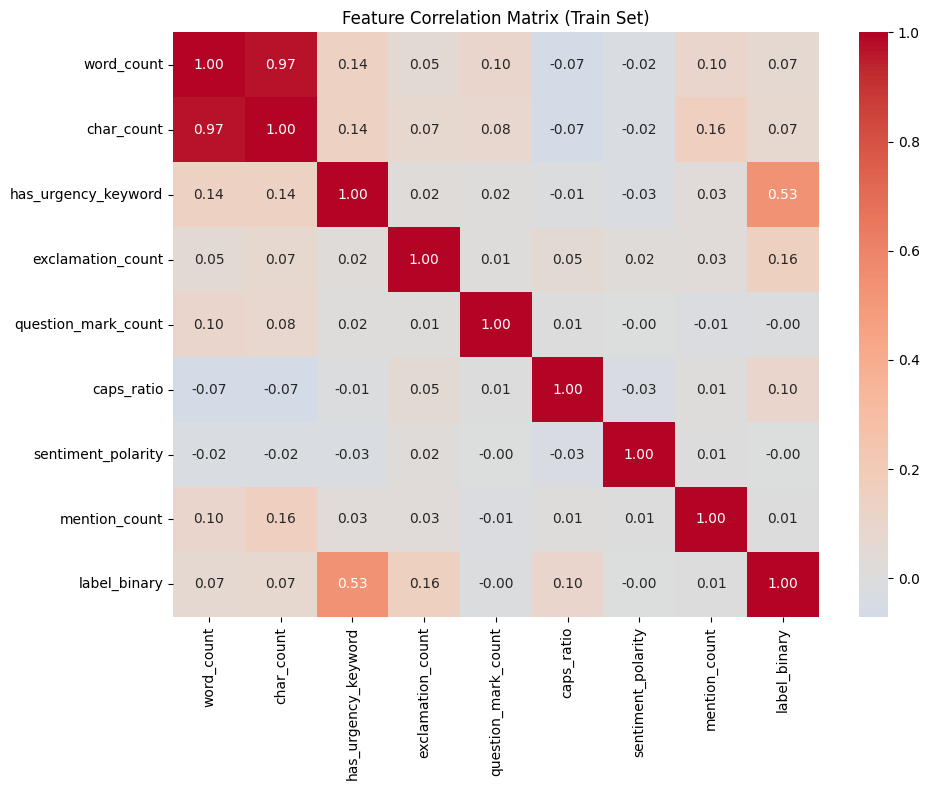

Correlation with label_binary (sorted):
label_binary           1.000000
has_urgency_keyword    0.533783
exclamation_count      0.158864
caps_ratio             0.097429
char_count             0.072938
word_count             0.071272
mention_count          0.007153
sentiment_polarity    -0.000370
question_mark_count   -0.004328
Name: label_binary, dtype: float64


In [198]:
FEATURE_COLS = [
    'word_count',
    'char_count',
    'has_urgency_keyword',
    'exclamation_count',
    'question_mark_count',
    'caps_ratio',
    'sentiment_polarity',
    'mention_count'
]

# Add binary label for correlation analysis
feats_train_corr = feats_train[FEATURE_COLS].copy()
feats_train_corr['label_binary'] = (y_train.values == 'URGENT').astype(int)

corr = feats_train_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix (Train Set)')
plt.tight_layout()
plt.show()

print('Correlation with label_binary (sorted):')
print(corr['label_binary'].sort_values(ascending=False))

### Notes

High correlation between two features means redundancy. High correlation with label_binary means signal. has_urgency_keyword expected strongest; sentiment_polarity expected negative. Computed on train only to avoid leaking test statistics.

## 14) Feature Distribution Plots

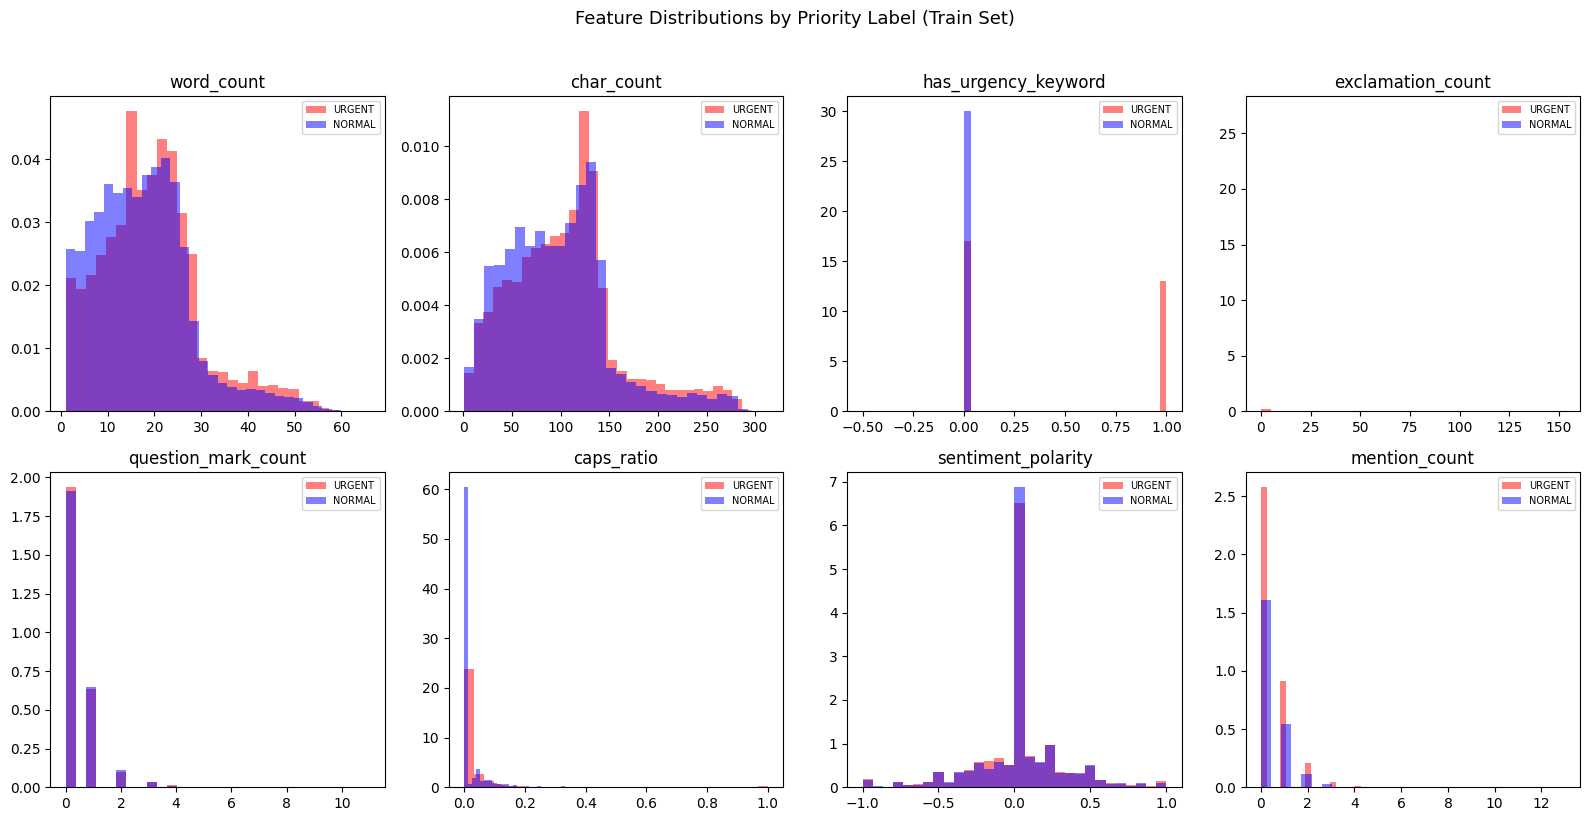

In [199]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    for label, color in [('URGENT', 'red'), ('NORMAL', 'blue')]:
        mask = y_train.values == label
        axes[i].hist(
            feats_train.loc[feats_train.index[mask], col],
            bins=30, alpha=0.5, color=color, label=label, density=True
        )
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Priority Label (Train Set)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### Notes

Well-separated URGENT/NORMAL distributions indicate strong signal. has_urgency_keyword is the strongest separator. caps_ratio and exclamation_count shift right for URGENT. word_count and mention_count show weak separation. density=True normalizes so class sizes do not distort the comparison.

## 15) Save Feature DataFrames

In [200]:
# Combine 8 features + label into train/val/test CSVs for Plan 02 (ML training)
train_ml = feats_train[FEATURE_COLS].copy()
train_ml['priority'] = y_train.values

val_ml = feats_val[FEATURE_COLS].copy()
val_ml['priority'] = y_val.values

test_ml = feats_test[FEATURE_COLS].copy()
test_ml['priority'] = y_test.values

train_ml.to_csv(DATA_DIR / 'train_features.csv', index=False)
val_ml.to_csv(DATA_DIR / 'val_features.csv', index=False)
test_ml.to_csv(DATA_DIR / 'test_features.csv', index=False)

print(f'Saved train_features.csv: {train_ml.shape}')
print(f'Saved val_features.csv:   {val_ml.shape}')
print(f'Saved test_features.csv:  {test_ml.shape}')
print(f'\nFeature columns: {FEATURE_COLS}')
print(f'\nTrain label distribution:')
print(train_ml['priority'].value_counts())

Saved train_features.csv: (34490, 9)
Saved val_features.csv:   (7367, 9)
Saved test_features.csv:  (7387, 9)

Feature columns: ['word_count', 'char_count', 'has_urgency_keyword', 'exclamation_count', 'question_mark_count', 'caps_ratio', 'sentiment_polarity', 'mention_count']

Train label distribution:
priority
NORMAL    17979
URGENT    16511
Name: count, dtype: int64


### Notes

Feature CSVs are saved so the ML training section loads them directly without recomputing. index=False keeps the split index out of the feature matrix.

Artifacts after this cell:
- data/clean_tickets.csv
- data/train_features.csv
- data/val_features.csv
- data/test_features.csv

## Why F1, Not Accuracy?

This is a classification problem. Accuracy is misleading when classes are close to balanced: a model predicting NORMAL every time still scores ~52%.

F1 on the URGENT class is the primary metric. It penalizes both missing real urgent tickets (false negatives) and triggering false alarms (false positives). Missing an urgent ticket costs more than a false alarm.

### Notes

The naive baseline gets 52% accuracy by predicting NORMAL for everything and 0.0 URGENT F1. Any useful model must beat both numbers.

## 15) Naive Baseline

In [201]:
import pandas as pd
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Load feature sets produced by Plan 01 Section 15
FEATURE_COLS = ['word_count', 'char_count', 'has_urgency_keyword',
                'exclamation_count', 'question_mark_count', 'caps_ratio',
                'sentiment_polarity', 'mention_count']

train_df = pd.read_csv('data/train_features.csv')
val_df   = pd.read_csv('data/val_features.csv')
test_df  = pd.read_csv('data/test_features.csv')

X_train_feat = train_df[FEATURE_COLS]
y_train       = train_df['priority']
X_val_feat   = val_df[FEATURE_COLS]
y_val         = val_df['priority']
X_test_feat  = test_df[FEATURE_COLS]
y_test        = test_df['priority']

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_feat, y_train)
y_pred_dummy = dummy.predict(X_val_feat)

print('=== Naive Baseline (Most Frequent Class) ===')
print(classification_report(y_val, y_pred_dummy))
dummy_acc = accuracy_score(y_val, y_pred_dummy)
dummy_f1  = f1_score(y_val, y_pred_dummy, pos_label='URGENT', average='binary', zero_division=0)
print(f'Val Accuracy: {dummy_acc:.3f} | Val F1 (URGENT): {dummy_f1:.3f}')

=== Naive Baseline (Most Frequent Class) ===
              precision    recall  f1-score   support

      NORMAL       0.52      1.00      0.69      3840
      URGENT       0.00      0.00      0.00      3527

    accuracy                           0.52      7367
   macro avg       0.26      0.50      0.34      7367
weighted avg       0.27      0.52      0.36      7367

Val Accuracy: 0.521 | Val F1 (URGENT): 0.000


### Notes

Majority-class predictor sets the floor. Val F1 of 0.0 with 52% accuracy is expected and confirms F1 is the right metric to optimize.

## 16) Classifier Pipelines

In [202]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

RANDOM_STATE = 42

pipelines = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ])
}

print('Pipelines configured:')
for name, pipe in pipelines.items():
    print(f'  {name}: {[s[0] for s in pipe.steps]}')

Pipelines configured:
  Logistic Regression: ['imputer', 'scaler', 'clf']
  Random Forest: ['imputer', 'scaler', 'clf']
  Gradient Boosting: ['imputer', 'scaler', 'clf']


### Notes

Three models cover the linear-to-ensemble spectrum:
- Logistic Regression: fast and interpretable, limited to linear boundaries
- Random Forest: handles feature interactions, robust to noise
- Gradient Boosting: sequential error correction, typically strongest

All wrapped in a Pipeline so the scaler fits on train only and the same object is used at inference without extra steps.

## 17) 5-Fold Cross-Validation

In [203]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
import time

# Wrap in a plain function so zero_division=0 is always applied at call time.
# make_scorer(f1_score, ..., zero_division=0) silently drops zero_division in
# sklearn >=1.4, causing NaN when a fold predicts only one class.
def safe_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

scorer = make_scorer(safe_f1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, pipe in pipelines.items():
    t0 = time.time()
    result = cross_validate(pipe, X_train_feat, y_train, cv=cv, scoring=scorer, n_jobs=-1)
    scores = result["test_score"]
    elapsed = time.time() - t0
    cv_results[name] = {
        "cv_mean": scores.mean(),
        "cv_std": scores.std(),
        "cv_scores": scores.tolist(),
        "elapsed_s": elapsed
    }
    print(f"{name}: CV F1 = {scores.mean():.3f} +/- {scores.std():.3f}  ({elapsed:.1f}s)")

Logistic Regression: CV F1 = 0.751 +/- 0.004  (13.6s)
Random Forest: CV F1 = 0.733 +/- 0.004  (16.1s)
Gradient Boosting: CV F1 = 0.765 +/- 0.005  (3.9s)


### Notes

safe_f1 wraps f1_score so zero_division=0 is always applied at call time. Passing it as a keyword through make_scorer is silently dropped in sklearn >= 1.4, which returns NaN for folds that predict only one class.

StratifiedKFold with shuffle=True preserves class ratios per fold. n_jobs=-1 runs folds in parallel. Val and test sets are never touched here.

## 18) Model Comparison

In [204]:
import warnings
warnings.filterwarnings('ignore')

# Train all pipelines on full train set, evaluate on val
val_results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train_feat, y_train)
    y_pred = pipe.predict(X_val_feat)
    val_results[name] = {
        'val_accuracy': accuracy_score(y_val, y_pred),
        'val_f1': f1_score(y_val, y_pred, pos_label='URGENT', average='binary', zero_division=0),
    }

summary_rows = []
for name in pipelines:
    summary_rows.append({
        'Model': name,
        'CV F1 (mean)': round(cv_results[name]['cv_mean'], 3),
        'CV F1 (std)': round(cv_results[name]['cv_std'], 3),
        'Val Accuracy': round(val_results[name]['val_accuracy'], 3),
        'Val F1 (URGENT)': round(val_results[name]['val_f1'], 3),
    })

# Add dummy row at the top
summary_rows.insert(0, {
    'Model': 'Naive Baseline',
    'CV F1 (mean)': '--',
    'CV F1 (std)': '--',
    'Val Accuracy': round(dummy_acc, 3),
    'Val F1 (URGENT)': round(dummy_f1, 3),
})

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index('Model')
print(summary_df.to_string())
summary_df

                    CV F1 (mean) CV F1 (std)  Val Accuracy  Val F1 (URGENT)
Model                                                                      
Naive Baseline                --          --         0.521            0.000
Logistic Regression        0.751       0.004         0.760            0.702
Random Forest              0.733       0.004         0.740            0.694
Gradient Boosting          0.765       0.005         0.783            0.707


,CV F1 (mean),CV F1 (std),Val Accuracy,Val F1 (URGENT)
Model,,,,
Naive Baseline,--,--,0.521,0.000
Logistic Regression,0.751,0.004,0.760,0.702
Random Forest,0.733,0.004,0.740,0.694
Gradient Boosting,0.765,0.005,0.783,0.707


### Notes

CV F1 close to Val F1 means no overfitting to a lucky split. Val Accuracy is included for context only: a model can score high accuracy by predicting NORMAL for everything.

## 19) Select Best Model

### Selection Criteria

Winner is the model with highest Val F1 (URGENT). CV F1 mean confirms it is not a fluke from one split. Lower CV std preferred for stability.

Note: metrics are against weak-supervision labels, not ground truth. The numbers are directionally correct but not a claim of real-world accuracy.

In [205]:
# Select best by Val F1 (URGENT)
best_name = max(val_results, key=lambda k: val_results[k]['val_f1'])
best_pipe = pipelines[best_name]
print(f'Selected: {best_name}')
print(f'Val F1 (URGENT): {val_results[best_name]["val_f1"]:.3f}')
print(f'Val Accuracy:    {val_results[best_name]["val_accuracy"]:.3f}')

Selected: Gradient Boosting
Val F1 (URGENT): 0.707
Val Accuracy:    0.783


### Notes

best_pipe is already fitted from Section 18. No re-fitting needed. Val F1 (URGENT) is the selection criterion because missing a real urgent ticket is costlier than a false alarm.

## 20) Confusion Matrix

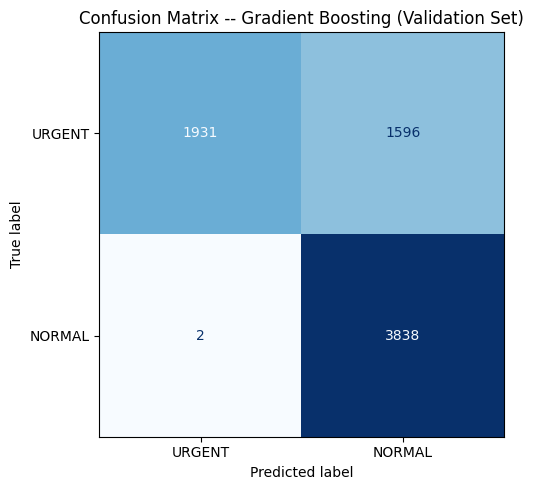

              precision    recall  f1-score   support

      NORMAL       0.71      1.00      0.83      3840
      URGENT       1.00      0.55      0.71      3527

    accuracy                           0.78      7367
   macro avg       0.85      0.77      0.77      7367
weighted avg       0.85      0.78      0.77      7367



In [206]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred_best = best_pipe.predict(X_val_feat)
cm = confusion_matrix(y_val, y_pred_best, labels=['URGENT', 'NORMAL'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['URGENT', 'NORMAL'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix -- {best_name} (Validation Set)')
plt.tight_layout()
plt.show()

print(classification_report(y_val, y_pred_best))

### Notes

Top-left: caught URGENT. Top-right: missed URGENT (costly). Bottom-left: false alarm. Bottom-right: correctly dismissed.

labels=[URGENT, NORMAL] forces URGENT to top-left so the positive class is in the standard position.

## 21) Feature Importances

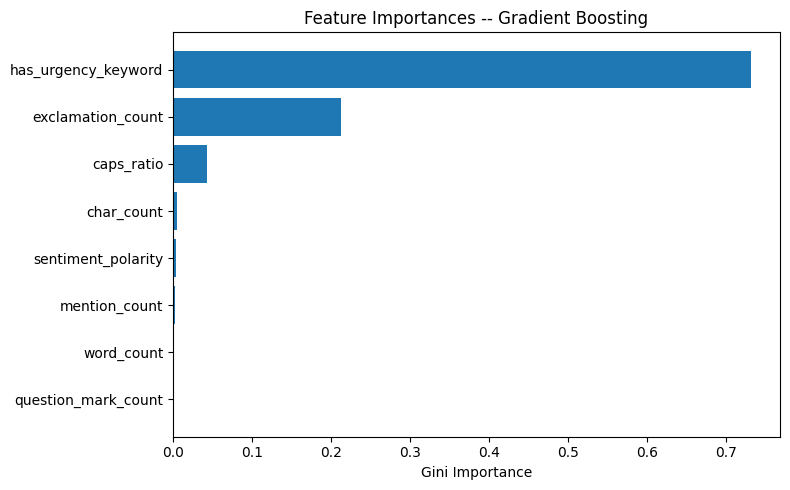

            Feature  Importance
has_urgency_keyword    0.732031
  exclamation_count    0.212070
         caps_ratio    0.042758
         char_count    0.004756
 sentiment_polarity    0.003283
      mention_count    0.002162
         word_count    0.001721
question_mark_count    0.001219


In [207]:
# Extract feature importances -- works for RF and GB; use coef_ for LR
clf = best_pipe.named_steps['clf']
if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    imp_type = 'Gini Importance'
elif hasattr(clf, 'coef_'):
    importances = np.abs(clf.coef_[0])
    imp_type = 'Absolute Coefficient'
else:
    importances = np.ones(len(FEATURE_COLS))
    imp_type = 'Uniform (not available)'

imp_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.xlabel(imp_type)
plt.title(f'Feature Importances -- {best_name}')
plt.tight_layout()
plt.show()
print(imp_df.sort_values('Importance', ascending=False).to_string(index=False))

### Notes

RF and GB expose feature_importances_ (Gini). LR uses abs(coef_). named_steps["clf"] pulls the classifier out of the Pipeline without breaking the abstraction.

### Is the Model Learning Urgency or Memorizing the Labeling Rules?

Both, to some degree. Labels came from a function that used has_urgency_keyword and caps_ratio. If those rank first in importances, the model is reproducing the rule as a fast deployable version.

If sentiment_polarity or word_count rank high alongside them, the model found signal beyond the rules. Either outcome is acceptable under weak supervision. A production system should revisit labels using behavioral feedback like escalation rate or resolution time.

## 22) Test Set Evaluation

In [208]:
print(f'=== Final Evaluation: {best_name} on Test Set ===')
y_pred_test = best_pipe.predict(X_test_feat)
test_acc = accuracy_score(y_test, y_pred_test)
test_f1  = f1_score(y_test, y_pred_test, pos_label='URGENT', average='binary', zero_division=0)

print(classification_report(y_test, y_pred_test))
print(f'Test Accuracy:    {test_acc:.3f}')
print(f'Test F1 (URGENT): {test_f1:.3f}')

# At-scale cost comparison (Phase 2 will surface this in the UI)
tickets_per_hour = 10_000
llm_cost_per_ticket = 0.0001  # approximate Groq cost per query (tokens x rate)
ml_cost_per_ticket  = 0.0     # ML inference is $0.00

ml_hourly  = ml_cost_per_ticket * tickets_per_hour
llm_hourly = llm_cost_per_ticket * tickets_per_hour

print(f'\n=== At-Scale Projection (10,000 tickets/hour) ===')
print(f'ML Classifier:   ${ml_hourly:.2f}/hour')
print(f'LLM Zero-Shot:   ${llm_hourly:.2f}/hour')
print(f'LLM cost vs ML:  infinity (ML=$0.00, LLM=${llm_hourly:.2f}/hour)')

=== Final Evaluation: Gradient Boosting on Test Set ===
              precision    recall  f1-score   support

      NORMAL       0.71      1.00      0.83      3851
      URGENT       1.00      0.56      0.71      3536

    accuracy                           0.79      7387
   macro avg       0.85      0.78      0.77      7387
weighted avg       0.85      0.79      0.78      7387

Test Accuracy:    0.787
Test F1 (URGENT): 0.715

=== At-Scale Projection (10,000 tickets/hour) ===
ML Classifier:   $0.00/hour
LLM Zero-Shot:   $1.00/hour
LLM cost vs ML:  infinity (ML=$0.00, LLM=$1.00/hour)


### Notes

Test set is touched exactly once here. All model selection happened on val. A val-to-test F1 gap under 0.05 is expected without hyperparameter tuning.

ML cost per ticket is zero. LLM cost scales linearly with volume. Phase 2 replaces the estimate with real token cost from the API response.

## 23) Serialize Model

In [209]:
import pickle
from pathlib import Path

MODEL_PATH = Path('backend/app/models/priority_model.pkl')
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

# Serialize the full Pipeline (scaler + classifier)
# Phase 2 calls loaded_pipe.predict() and loaded_pipe.predict_proba() directly
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(best_pipe, f)
print(f'Model serialized to {MODEL_PATH}')
print(f'File size: {MODEL_PATH.stat().st_size / 1024:.1f} KB')

# Verify: reload and confirm predictions match
with open(MODEL_PATH, 'rb') as f:
    loaded_pipe = pickle.load(f)

y_verify   = loaded_pipe.predict(X_test_feat[:5])
y_original = best_pipe.predict(X_test_feat[:5])
assert list(y_verify) == list(y_original), 'Reload mismatch!'
print(f'Reload verification PASSED. Sample predictions: {list(y_verify)}')

# Show confidence scores (for ML-05 requirement: label + confidence + latency)
y_proba = loaded_pipe.predict_proba(X_test_feat[:5])
print(f'\nSample predict_proba output (first 5 test rows):')
print(pd.DataFrame(y_proba, columns=loaded_pipe.classes_).round(3))
print(f'\nClasses order: {list(loaded_pipe.classes_)}')
print('(Phase 2: confidence = predict_proba row max; URGENT index = classes_.tolist().index("URGENT"))')

Model serialized to backend\app\models\priority_model.pkl
File size: 125.0 KB
Reload verification PASSED. Sample predictions: ['URGENT', 'NORMAL', 'NORMAL', 'NORMAL', 'NORMAL']

Sample predict_proba output (first 5 test rows):
   NORMAL  URGENT
0   0.004   0.996
1   0.702   0.298
2   0.751   0.249
3   0.694   0.306
4   0.748   0.252

Classes order: ['NORMAL', 'URGENT']
(Phase 2: confidence = predict_proba row max; URGENT index = classes_.tolist().index("URGENT"))


### Notes

The full Pipeline is serialized, not just the classifier. Pickling only the clf would break inference because raw features are not what the model trained on.

Reload verification checks that predictions match before and after the round-trip. predict_proba column order is retrieved with classes_.tolist().index("URGENT"), never hardcoded.

## Production Recommendation

Deploy the ML classifier. At 10K tickets per hour the LLM zero-shot approach costs around $1/hour while the ML model costs nothing. The ML model is also deterministic and sub-millisecond at inference.

LLM zero-shot is worth considering in low-volume, high-stakes contexts where label noise is a concern or no labeled data exists yet. For this use case the ML model is the right call, and the LLM prediction is shown alongside it in the UI as a comparison point.

## 23b) Chroma Vector Store

No chunking needed. Each document is a tweet+reply pair under 280 characters, well within all-MiniLM-L6-v2's 512-token context. Splitting would break semantically complete units and hurt retrieval quality.

In [210]:
# Install if needed: pip install chromadb sentence-transformers
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction
import pandas as pd
from pathlib import Path

CHROMA_PATH = Path('data/chroma_store')
EMBEDDING_MODEL = 'all-MiniLM-L6-v2'
COLLECTION_NAME = 'customer_tickets'
TOP_K = 3

# Load cleaned pairs (full text needed — not just feature CSVs)
df = pd.read_csv('data/clean_tickets.csv')
print(f'Loaded {len(df):,} rows from clean_tickets.csv')
print(f'Columns: {list(df.columns)}')

# Build document strings: customer tweet + company reply
# clean_text_lower used for embedding (consistent with keyword detection)
df['document'] = (
    df['clean_text_lower'].fillna('')
    + '\n\nResolution: '
    + df['reply_text'].fillna('')
)
print(f'\nSample document:')
print(df['document'].iloc[0][:300])


Loaded 49,244 rows from clean_tickets.csv
Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id', 'reply_tweet_id', 'reply_text', 'reply_created_at', 'tweet_length', 'clean_text', 'clean_text_lower', 'priority']

Sample document:
could you start selling fruit pots on your trains please? @virgintrains, healthier options really wouldn't go amiss.

Resolution: @459301 We will be sure to pass this idea on :) ^LC


In [211]:
# Initialize Chroma persistent client
CHROMA_PATH.mkdir(parents=True, exist_ok=True)
client = chromadb.PersistentClient(path=str(CHROMA_PATH))

embedding_fn = SentenceTransformerEmbeddingFunction(model_name=EMBEDDING_MODEL)

# Get or create collection (idempotent — safe to re-run)
collection = client.get_or_create_collection(
    name=COLLECTION_NAME,
    embedding_function=embedding_fn,
    metadata={'hnsw:space': 'cosine'},
)

# Check if already populated
existing_count = collection.count()
if existing_count >= len(df):
    print(f'Collection already has {existing_count:,} documents — skipping embedding.')
else:
    # Batch embed in chunks of 500 for memory safety
    BATCH_SIZE = 500
    docs  = df['document'].tolist()
    ids   = [f'ticket_{i}' for i in range(len(df))]
    metas = [{'priority': row['priority']} for _, row in df.iterrows()]

    print(f'Embedding {len(docs):,} documents in batches of {BATCH_SIZE}...')
    for start in range(0, len(docs), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(docs))
        collection.add(
            documents=docs[start:end],
            ids=ids[start:end],
            metadatas=metas[start:end],
        )
        if start % 5000 == 0:
            print(f'  Progress: {end:,} / {len(docs):,}')

    print(f'\nChroma collection count: {collection.count():,}')


Embedding 49,244 documents in batches of 500...
  Progress: 500 / 49,244
  Progress: 5,500 / 49,244
  Progress: 10,500 / 49,244
  Progress: 15,500 / 49,244
  Progress: 20,500 / 49,244
  Progress: 25,500 / 49,244
  Progress: 30,500 / 49,244
  Progress: 35,500 / 49,244
  Progress: 40,500 / 49,244
  Progress: 45,500 / 49,244

Chroma collection count: 49,244


In [212]:
# Verify retrieval works with a test query
test_query = 'my account was hacked and I cannot log in'
results = collection.query(
    query_texts=[test_query],
    n_results=TOP_K,
)

print(f'Test query: "{test_query}"\n')
for i, (doc, dist) in enumerate(
    zip(results['documents'][0], results['distances'][0])
):
    similarity = 1 - dist  # cosine distance -> similarity
    print(f'--- Result {i+1} (similarity={similarity:.3f}) ---')
    print(doc[:200])
    print()

print(f'\nChroma store saved to: {CHROMA_PATH}')


Test query: "my account was hacked and I cannot log in"

--- Result 1 (similarity=0.758) ---
how do i fix a hacked account if i can’t change my password?

Resolution: @260692 Here to help! Send us a note at https://t.co/kGIXas5Cxg so our team can connect.

--- Result 2 (similarity=0.748) ---
thanks for that lack of help i got after my account was hacked.

Resolution: @282924 Hi can you elaborate for us? Did you contact our account safety team? ^SG

--- Result 3 (similarity=0.724) ---
my account has been hacked can someone help me please

Resolution: @719925 Hello Kyle! Please check your DMs for assistance.


Chroma store saved to: data\chroma_store


### Notes

Pairs are stored so retrieved context includes resolutions, not just complaints. Cosine space is correct for sentence embeddings. The idempotent count check skips re-embedding if the collection is already populated. Chroma returns cosine distance so 1 - distance converts to similarity for display.

## 24) Summary

In [213]:
print('=' * 60)
print('PHASE 1 PLAN 02 SUMMARY')
print('=' * 60)
print(f'\nDataset: {len(train_df) + len(val_df) + len(test_df):,} labeled ticket pairs')
print(f'URGENT rate (train): {(train_df["priority"]=="URGENT").mean():.1%}')
print(f'\nBest model: {best_name}')
print(f'Test F1 (URGENT): {test_f1:.3f}')
print(f'Test Accuracy:    {test_acc:.3f}')
print(f'\nArtifacts produced:')
print(f'  data/train_features.csv         -- 8-feature train set')
print(f'  data/val_features.csv           -- 8-feature val set')
print(f'  data/test_features.csv          -- 8-feature test set')
print(f'  backend/app/models/priority_model.pkl -- serialized Pipeline ({MODEL_PATH.stat().st_size / 1024:.1f} KB)')
print(f'\nModel classes: {list(loaded_pipe.classes_)}')
print(f'URGENT index in predict_proba: {list(loaded_pipe.classes_).index("URGENT")}')

PHASE 1 PLAN 02 SUMMARY

Dataset: 49,244 labeled ticket pairs
URGENT rate (train): 47.9%

Best model: Gradient Boosting
Test F1 (URGENT): 0.715
Test Accuracy:    0.787

Artifacts produced:
  data/train_features.csv         -- 8-feature train set
  data/val_features.csv           -- 8-feature val set
  data/test_features.csv          -- 8-feature test set
  backend/app/models/priority_model.pkl -- serialized Pipeline (125.0 KB)

Model classes: ['NORMAL', 'URGENT']
URGENT index in predict_proba: 1


## Carry-Forward to Phase 2

FEATURE_COLS: word_count, char_count, has_urgency_keyword, exclamation_count, question_mark_count, caps_ratio, sentiment_polarity, mention_count

Model: backend/app/models/priority_model.pkl (full Pipeline)

Inference: loaded_pipe.predict(X)[0] and loaded_pipe.predict_proba(X)[0].max()

URGENT confidence column: classes_.tolist().index("URGENT"), not index 0 or 1

Chroma path: data/chroma_store, embedding model: all-MiniLM-L6-v2

Labels are weak-supervision proxies. Disclose this in the pitch.

### Notes

Update the carry-forward section if FEATURE_COLS or the model interface changes. Phase 2 should not need to re-read this notebook.